## Monte Carlo Simulation for Approximating Pi

This notebook demonstrates the Monte Carlo method to approximate the value of Pi. It simulates random points within a square and determines how many of these points fall within an inscribed circle. The ratio of points inside the circle to the total number of points, scaled by 4, provides an approximation of Pi.

The simulation includes dynamic visualization of the generated points and the evolving approximation of Pi over time.

In [11]:
#imports
import numpy as np
from os import times
import time
from IPython.display import clear_output, display, Image
import matplotlib.pyplot as plt
from io import BytesIO

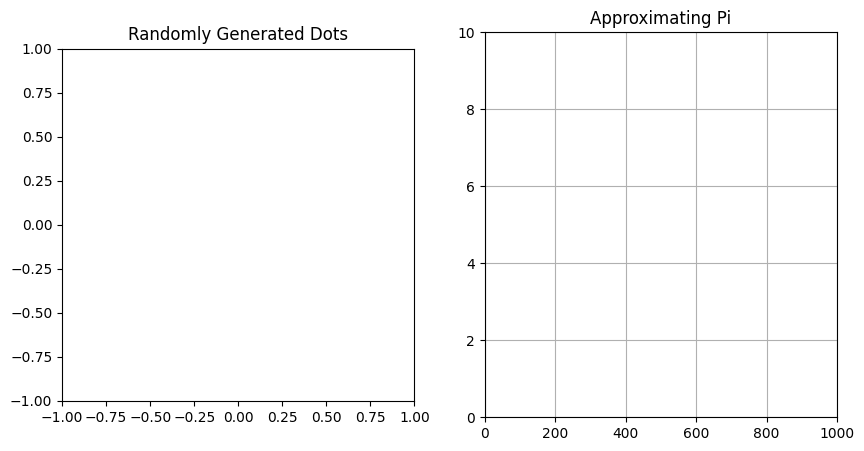

In [8]:
def plot_construction():
  fig,axis= plt.subplots(1,2,figsize=(10,5))
  # Generated Dots
  axis[0].set_title("Randomly Generated Dots")
  axis[0].set_aspect("equal")
  axis[0].set_xlim([-1,1])
  axis[0].set_ylim([-1,1])
  # Plot of Approximated
  axis[1].set_title("Approximating Pi")
  axis[1].set_xlim([0,1000])
  axis[1].set_ylim([0,10])
  axis[1].grid()
  return fig, axis # Return both fig and axis
fig, axis=plot_construction()

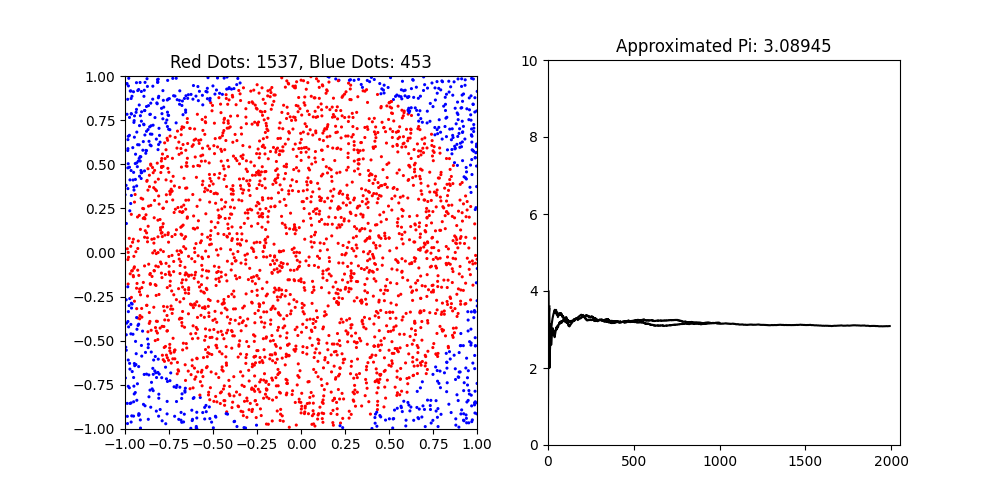

In [13]:

N_samples= np.arange(1,2000)
pi_counter=0

dots_x=[]
dots_y=[]
dots_colour= []
pi_array=[]

# Initialize plot objects once before the loop
scatter = axis[0].scatter([], [], color=[], marker='o', s=5)
plot, = axis[1].plot([], [], 'black') # Initialize with empty lists for x and y

# Set static titles and limits once
axis[0].set_title("Randomly Generated Dots")
axis[0].set_aspect("equal")
axis[0].set_xlim([-1,1])
axis[0].set_ylim([-1,1])
axis[1].set_title("Approximating Pi")
axis[1].set_xlim([0,1000]) # Initial x-limit for pi approximation
axis[1].set_ylim([0,10]) # Initial y-limit for pi approximation
axis[1].grid()

for N in N_samples:
    x=np.random.uniform(-1,1)
    y=np.random.uniform(-1,1)

    dots_x.append(x)
    dots_y.append(y)

    if np.sqrt(x**2+y**2)<=1:
        pi_counter+=1
        dots_colour.append("red")
    else:
        dots_colour.append("blue")

    probability=pi_counter/N
    approx_pi=4*probability
    pi_array.append(approx_pi)

    # Update data of existing plot objects
    scatter.set_offsets(np.column_stack((dots_x, dots_y)))
    scatter.set_facecolors(dots_colour) # Use set_facecolors for color updates on scatter

    plot.set_data(range(1, N+1), pi_array) # Update the line data

    # Update titles dynamically
    axis[0].set_title(f"Red Dots: {pi_counter}, Blue Dots: {N-pi_counter}")
    axis[1].set_title(f"Approximated Pi: {approx_pi:.5f}")

    # Conditional redraw for performance and fluid animation
    if N % 10 == 0: # Redraw every 10 samples for smoother animation, or adjust as needed
        # Dynamically adjust x-axis limits for the pi approximation plot if needed
        if N > axis[1].get_xlim()[1]: # If current N exceeds the x-limit
            axis[1].set_xlim([0, N + 200]) # Extend x-axis

        clear_output(wait=True)

        # Explicitly save figure to a buffer and display it as an Image
        buf = BytesIO()
        fig.savefig(buf, format='png')
        buf.seek(0)
        display(Image(data=buf.getvalue()))

        plt.pause(0.001) # A small pause can help browser rendering

plt.show() # Ensure final plot is displayed
plt.close(fig) # Close the figure to release resources